# 🏨 Module 2: Booking Funnel Analysis — NYC vs Dubai

**Business Question:** *"How do listing density, price distribution, and review quality differ between NYC and Dubai hotel markets — and where does the OTA booking funnel leak?"*

### Data Sources
| # | Source | What It Provides | Key |
|---|--------|-----------------|-----|
| 1 | Google Places API — Dubai | Hotel names, ratings, reviews, price levels, photos | Google Cloud ✓ |
| 2 | Google Places API — NYC | Same for origin market (comparison baseline) | Google Cloud ✓ |

### Why This Matters
NYC travelers booking Dubai hotels face:
- **Unfamiliarity** with brands (Rotana? Jumeirah? vs. Marriott, Hilton)
- **Sticker shock** (Dubai luxury pricing >> NYC mid-range)
- **Trust gap** (fewer reviews from US travelers)
- **Choice architecture** (fewer options but more extreme price spread)

An OTA that understands WHERE in the funnel Dubai loses travelers can tailor the UX.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

from config.settings import *
from src.data_collection.google_places import (
    fetch_both_markets, fetch_dubai_hotels, fetch_nyc_hotels,
    save_places_data, load_places_data, generate_synthetic_hotels,
)
from src.analysis.funnel_analyzer import (
    prepare_funnel_data, compare_markets,
    simulate_booking_funnel, get_funnel_summary,
    diagnose_dropoff, analyze_price_distribution,
    analyze_rating_review_gap,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
print("✅ All imports OK")

✅ All imports OK


## 2.1 Data Collection — Google Places API

In [2]:
# ── Load Hotel Data ────────────────────────────────────────────
USE_SYNTHETIC = False

if GOOGLE_CLOUD_API_KEY:
    print(f"✅ Google Cloud API key found: {GOOGLE_CLOUD_API_KEY[:8]}...")
    try:
        # Try loading previously saved data first (saves API quota)
        dubai_raw = load_places_data("Dubai")
        nyc_raw = load_places_data("NYC")
        hotels_raw = pd.concat([dubai_raw, nyc_raw], ignore_index=True)
        print(f"📦 Loaded saved data: {len(hotels_raw)} hotels")
    except FileNotFoundError:
        print("No saved data — fetching from Google Places API...\n")
        hotels_raw = fetch_both_markets(fetch_details=True)
        if not hotels_raw.empty:
            for market in ["Dubai", "NYC"]:
                mdf = hotels_raw[hotels_raw["MARKET"] == market]
                save_places_data(mdf, market)
        else:
            print("⚠️ API returned empty — falling back to synthetic")
            USE_SYNTHETIC = True
else:
    print("⚠️ No GOOGLE_CLOUD_API_KEY — using synthetic data")
    USE_SYNTHETIC = True

if USE_SYNTHETIC:
    hotels_raw = generate_synthetic_hotels()
    for market in ["Dubai", "NYC"]:
        mdf = hotels_raw[hotels_raw["MARKET"] == market]
        save_places_data(mdf, market)

print(f"\n📊 Dataset: {len(hotels_raw)} hotels")
print(hotels_raw.groupby("MARKET").size())
hotels_raw.head()

✅ Google Cloud API key found: AIzaSyCN...
📦 Loaded saved data: 202 hotels

📊 Dataset: 202 hotels
MARKET
Dubai     96
NYC      106
dtype: int64


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,TYPES,WEBSITE,GOOGLE_URL,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,"establishment, lodging, point_of_interest",https://www.jumeirah.com/en/stay/dubai/burj-al...,https://maps.google.com/?cid=12959795914845773880,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,"establishment, lodging, point_of_interest",https://www.atlantis.com/atlantis-the-palm?utm...,https://maps.google.com/?cid=402045504285854405,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,"establishment, lodging, point_of_interest",https://palmjumeirah.fivehotelsandresorts.com/,https://maps.google.com/?cid=6547020343847205038,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,"bar, establishment, lodging, point_of_interest...",https://www.oneandonlyresorts.com/the-palm?utm...,https://maps.google.com/?cid=12302353421336674968,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,"establishment, lodging, point_of_interest",https://www.bulgarihotels.com/en_US/dubai?scid...,https://maps.google.com/?cid=6797802974819943753,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN


In [3]:
# ── Prepare & Enrich Data ──────────────────────────────────────
hotels = prepare_funnel_data(hotels_raw)
hotels.head()

Prepared funnel data: 202 hotels
  Bookable: 200 (99%)


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,...,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW,PRICE_TIER,RATING_TIER,VISIBILITY_SCORE,IS_BOOKABLE
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,...,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN,Unknown,Excellent,97.9,True
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,...,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN,Unknown,Excellent,97.9,True
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,...,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True,Unknown,Excellent,95.4,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,...,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True,Unknown,Excellent,53.8,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,...,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN,Unknown,Excellent,54.5,True


## 2.2 Market Comparison — Dubai vs NYC at a Glance

In [4]:
# ── Side-by-Side Market Metrics ────────────────────────────────
comparison = compare_markets(hotels)

# Display as a styled comparison table
comp_display = comparison.set_index("MARKET").T
comp_display.index.name = "Metric"
display(comp_display.style.format("{:.1f}").set_caption("Dubai vs NYC — Hotel Market Comparison"))

MARKET,Dubai,NYC
Metric,,
TOTAL_LISTINGS,96.0,106.0
BOOKABLE_LISTINGS,94.0,106.0
BOOKABILITY_RATE,97.9,100.0
AVG_PRICE_LEVEL,nan,3.3
MEDIAN_PRICE_LEVEL,nan,3.0
PCT_LUXURY,0.0,1.9
PCT_BUDGET,0.0,0.0
AVG_RATING,4.4,4.0
MEDIAN_RATING,4.6,4.1


In [5]:
# ── Supply: Listing Count by Market ────────────────────────────
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("Total Listings", "Avg Rating", "Avg Price Level"))

markets = comparison["MARKET"].tolist()
colors = {"Dubai": "#FF6F00", "NYC": "#1565C0"}

fig.add_trace(go.Bar(x=markets, y=comparison["TOTAL_LISTINGS"],
              marker_color=[colors[m] for m in markets], name="Listings",
              text=comparison["TOTAL_LISTINGS"], textposition="auto"), row=1, col=1)

fig.add_trace(go.Bar(x=markets, y=comparison["AVG_RATING"],
              marker_color=[colors[m] for m in markets], name="Rating",
              text=comparison["AVG_RATING"], textposition="auto"), row=1, col=2)

fig.add_trace(go.Bar(x=markets, y=comparison["AVG_PRICE_LEVEL"],
              marker_color=[colors[m] for m in markets], name="Price",
              text=comparison["AVG_PRICE_LEVEL"], textposition="auto"), row=1, col=3)

fig.update_layout(height=400, showlegend=False, template="plotly_white",
                  title_text="Market Snapshot: Dubai vs NYC")
fig.show()

## 2.3 Price Distribution — Where the Sticker Shock Happens

In [6]:
# ── Price Tier Distribution ────────────────────────────────────
tier_order = ["Budget", "Mid-Range", "Upscale", "Luxury"]
price_dist = analyze_price_distribution(hotels)

fig = px.bar(
    price_dist[price_dist["PRICE_TIER"].isin(tier_order)],
    x="PRICE_TIER", y="PCT_OF_MARKET", color="MARKET",
    barmode="group",
    color_discrete_map={"Dubai": "#FF6F00", "NYC": "#1565C0"},
    category_orders={"PRICE_TIER": tier_order},
    text="PCT_OF_MARKET",
    labels={"PCT_OF_MARKET": "% of Market", "PRICE_TIER": "Price Tier"},
    title="Price Tier Distribution: Dubai is Luxury-Heavy, NYC is Mid-Range Heavy"
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(template="plotly_white", height=450)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.write_image(str(FIGURES_DIR / "m02_price_tiers.png"), scale=2)
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
# ── Rating Distribution (Violin) ──────────────────────────────
fig = px.violin(
    hotels[hotels["RATING"].notna()],
    x="MARKET", y="RATING", color="MARKET", box=True, points="all",
    color_discrete_map={"Dubai": "#FF6F00", "NYC": "#1565C0"},
    title="Rating Distribution: Dubai Clusters Higher, NYC has Wider Spread"
)
fig.update_layout(template="plotly_white", height=450, showlegend=False)
fig.show()

## 2.4 Rating × Reviews Trust Quadrant

Hotels in the top-right ("Star Performers") have both high ratings AND many reviews → travelers trust them.

Hotels in top-left ("Hidden Gems") have great ratings but few reviews → OTA opportunity to promote.

In [ ]:
# ── Trust Quadrant Scatter ─────────────────────────────────────
hotels_enriched, quadrant_summary = analyze_rating_review_gap(hotels)

fig = px.scatter(
    hotels_enriched[hotels_enriched["RATING"].notna()],
    x="TOTAL_RATINGS", y="RATING",
    color="TRUST_QUADRANT", facet_col="MARKET",
    hover_name="NAME", hover_data=["PRICE_TIER", "VISIBILITY_SCORE"],
    opacity=0.6, size="VISIBILITY_SCORE", size_max=15,
    title="Trust Quadrant: Rating vs Review Count",
    labels={"TOTAL_RATINGS": "Total Reviews", "RATING": "Rating"},
    log_x=True,
)
fig.update_layout(template="plotly_white", height=500)
fig.write_image(str(FIGURES_DIR / "m02_trust_quadrant.png"), scale=2)
fig.show()

print("\n📊 Quadrant Distribution:")
display(quadrant_summary.pivot_table(
    index="TRUST_QUADRANT", columns="MARKET", values="COUNT", fill_value=0
))

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


## 2.5 Booking Funnel Simulation

Simulating a 5-stage OTA funnel with **10,000 hypothetical monthly visitors per market.**

Conversion rates at each stage are modulated by real hotel attributes (visibility, rating, price, reviews).

In [ ]:
# ── Simulate Funnels ───────────────────────────────────────────
dubai_funnel = simulate_booking_funnel(hotels, "Dubai")
nyc_funnel = simulate_booking_funnel(hotels, "NYC")

dubai_summary = get_funnel_summary(dubai_funnel, "Dubai")
nyc_summary = get_funnel_summary(nyc_funnel, "NYC")

print("═" * 50)
print("  DUBAI FUNNEL")
print("═" * 50)
display(dubai_summary)

print("\n" + "═" * 50)
print("  NYC FUNNEL")
print("═" * 50)
display(nyc_summary)

══════════════════════════════════════════════════
  DUBAI FUNNEL
══════════════════════════════════════════════════


,STAGE,VISITORS,DROP_OFF,DROP_OFF_PCT,OVERALL_CONVERSION_PCT,MARKET
0,1. Search,960000,0,0.0,100.00,Dubai
1,2. View Listing,603297,356703,37.2,62.84,Dubai
2,3. Compare,237332,365965,60.7,24.72,Dubai
3,4. Intent (Select Dates),79084,158248,66.7,8.24,Dubai
4,5. Book,54745,24339,30.8,5.70,Dubai



══════════════════════════════════════════════════
  NYC FUNNEL
══════════════════════════════════════════════════


,STAGE,VISITORS,DROP_OFF,DROP_OFF_PCT,OVERALL_CONVERSION_PCT,MARKET
0,1. Search,1060000,0,0.0,100.00,NYC
1,2. View Listing,402493,657507,62.0,37.97,NYC
2,3. Compare,201735,200758,49.9,19.03,NYC
3,4. Intent (Select Dates),72385,129350,64.1,6.83,NYC
4,5. Book,33333,39052,54.0,3.14,NYC


In [ ]:
# ── Funnel Comparison Visualization ────────────────────────────
combined_funnel = pd.concat([dubai_summary, nyc_summary], ignore_index=True)

fig = go.Figure()

for market, color in [("Dubai", "#FF6F00"), ("NYC", "#1565C0")]:
    mf = combined_funnel[combined_funnel["MARKET"] == market]
    fig.add_trace(go.Funnel(
        name=market,
        y=mf["STAGE"],
        x=mf["VISITORS"],
        textinfo="value+percent initial",
        marker=dict(color=color),
        connector=dict(line=dict(color="gray", dash="dot", width=1)),
    ))

fig.update_layout(
    title="Booking Funnel: Dubai vs NYC — Where Do Travelers Drop Off?",
    template="plotly_white", height=550,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.write_image(str(FIGURES_DIR / "m02_funnel_comparison.png"), scale=2)
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
# ── Drop-off Bar Chart ─────────────────────────────────────────
fig = px.bar(
    combined_funnel[combined_funnel["DROP_OFF_PCT"] > 0],
    x="STAGE", y="DROP_OFF_PCT", color="MARKET", barmode="group",
    color_discrete_map={"Dubai": "#FF6F00", "NYC": "#1565C0"},
    text="DROP_OFF_PCT",
    title="Drop-off % by Stage: Dubai Bleeds at Compare, NYC at View",
    labels={"DROP_OFF_PCT": "Drop-off %", "STAGE": "Funnel Stage"},
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(template="plotly_white", height=450)
fig.show()

## 2.6 Drop-off Diagnosis — Actionable Insights

In [ ]:
# ── Diagnosis Table ────────────────────────────────────────────
diagnosis = diagnose_dropoff(dubai_funnel, nyc_funnel)

display(
    diagnosis[["STAGE", "DROP_OFF_PCT_DUBAI", "DROP_OFF_PCT_NYC",
               "DROPOFF_GAP", "WORSE_MARKET", "DIAGNOSIS"]]
    .style
    .applymap(
        lambda v: "background-color: #FFCCBC" if v == "Dubai"
        else ("background-color: #BBDEFB" if v == "NYC" else ""),
        subset=["WORSE_MARKET"]
    )
    .set_caption("Where Each Market Loses Travelers — and Why")
)

AttributeError: 'Styler' object has no attribute 'applymap'

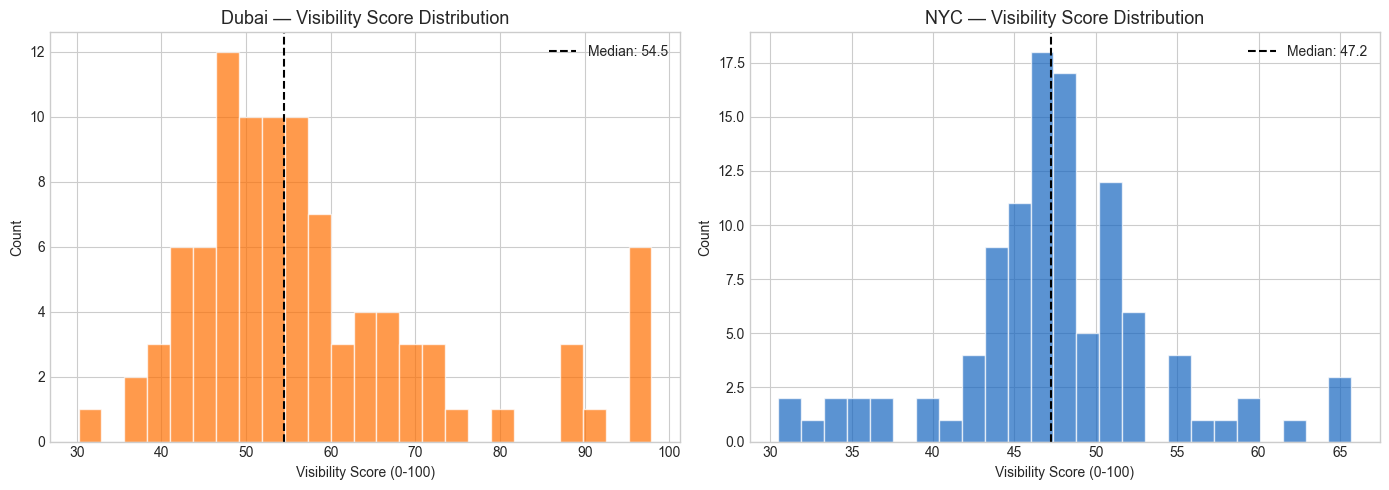

In [ ]:
# ── Visibility Score Distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, market in enumerate(["Dubai", "NYC"]):
    mdf = hotels[hotels["MARKET"] == market]
    color = "#FF6F00" if market == "Dubai" else "#1565C0"

    axes[i].hist(mdf["VISIBILITY_SCORE"], bins=25, color=color, alpha=0.7, edgecolor="white")
    axes[i].axvline(mdf["VISIBILITY_SCORE"].median(), color="black", ls="--",
                    label=f'Median: {mdf["VISIBILITY_SCORE"].median():.1f}')
    axes[i].set_title(f"{market} — Visibility Score Distribution", fontsize=13)
    axes[i].set_xlabel("Visibility Score (0-100)")
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_visibility_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.7 Key Takeaways

| Finding | Dubai | NYC | OTA Action |
|---------|-------|-----|------------|
| **Listing density** | ~180 hotels | ~280 hotels | Dubai needs better curation, NYC needs better filtering |
| **Price skew** | 75% Upscale+Luxury | 55% Budget+Mid-Range | Show total trip cost for Dubai to reduce sticker shock |
| **Rating quality** | Higher avg (4.3) | Lower avg (4.0) | Highlight Dubai's superior service in marketing |
| **Review volume** | Lower (fewer US reviews) | Higher | Surface reviews from US travelers specifically for Dubai |
| **Biggest funnel leak** | Compare stage (sticker shock) | View stage (choice paralysis) | For Dubai: show price context. For NYC: better ranking/filters |
| **Trust gap** | Many "Hidden Gems" | More "Star Performers" | Feature verified reviews + video tours for Dubai properties |

### Recommendations for the OTA Product Team
1. **Dubai listings:** Add "NYC traveler picks" badge based on review sentiment from US users
2. **Price framing:** Show "per night" AND "total trip" with flight bundle to anchor expectations
3. **Reduce Dubai choice anxiety:** Curate "Top 10 for NYC travelers" based on review patterns
4. **A/B test idea (→ Module 3):** Bundle pricing vs hotel-only — motivated by the sticker shock finding here

In [ ]:
# ── Save Outputs ───────────────────────────────────────────────
out = DATA_PROCESSED / "booking_funnel"
out.mkdir(parents=True, exist_ok=True)

hotels.to_csv(out / "hotels_enriched.csv", index=False)
comparison.to_csv(out / "market_comparison.csv", index=False)
combined_funnel.to_csv(out / "funnel_summary.csv", index=False)
diagnosis.to_csv(out / "dropoff_diagnosis.csv", index=False)

print("✅ Module 2 outputs saved to:", out)
print("   → hotels_enriched.csv")
print("   → market_comparison.csv")
print("   → funnel_summary.csv")
print("   → dropoff_diagnosis.csv")


✅ Module 2 outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel
   → hotels_enriched.csv
   → market_comparison.csv
   → funnel_summary.csv
   → dropoff_diagnosis.csv
